# Module 14 · The DFT, the FFT and discrete-time random processes

**Book source:** Bracewell, chapter 11, pp. 258–292; Barkat, chapter 4, pp. 223–290

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. The DFT, theorems and short pairs
🎯 **What question does this method answer?** Does our own DFT match the library, and do the short pairs and theorems (shift, convolution, Parseval, packing, stretching) hold numerically?

In [2]:
trap = getattr(np, "trapezoid", None) or np.trapz
rg = np.random.default_rng(14)
def dft(f):
    f = np.asarray(f, complex); N = len(f); t = np.arange(N)
    return np.array([np.sum(f*np.exp(-2j*np.pi*v*t/N)) for v in range(N)])/N
def idft(F):
    F = np.asarray(F, complex); N = len(F); v = np.arange(N)
    return np.array([np.sum(F*np.exp(2j*np.pi*v*t/N)) for t in range(N)])
def cconv(a, b):
    N = len(a); return np.array([sum(a[k]*b[(t-k) % N] for k in range(N)) for t in range(N)])
f4 = np.array([1, 2, 3, 4.]); F4 = dft(f4)
assert np.allclose(F4, np.fft.fft(f4)/4) and np.allclose(F4, [2.5, (-2+2j)/4, -0.5, (-2-2j)/4])
W4 = np.exp(-2j*np.pi/4); Mx = W4**np.outer(np.arange(4), np.arange(4)); assert np.allclose(Mx@f4/4, F4)
report("d4_F0", F4[0].real, ".2f"); report("d4_F1re", F4[1].real, ".2f"); report("d4_F1im", F4[1].imag, ".2f")
xr = rg.standard_normal(16); assert np.allclose(idft(dft(xr)), xr)
report("inv_dev", max(np.max(np.abs(idft(dft(xr)) - xr)), 1e-16), ".0e")
ts = np.array([-0.25, -0.15, -0.05, 0.05, 0.15, 0.25]); xs = np.cos(2*np.pi*ts)
assert abs(xs[1] - 0.5878) < 1e-4 and abs(xs[2] - 0.9511) < 1e-4
report("tb_a", xs[1], ".3f"); report("tb_b", xs[2], ".3f")
# negative frequency indices
N = 1024; v = 724
fneg = (v - N)/N
assert abs(np.fft.fftfreq(N)[v] - fneg) < 1e-15
report("v724", v/N, ".3f"); report("fneg", fneg, ".4f")
X = np.fft.fft(rg.standard_normal(N))
assert np.allclose(X[1:], np.conj(X[:0:-1])) and abs(X[0].imag) < 1e-9 and abs(X[N//2].imag) < 1e-9
assert 2 + 2*(N//2 - 1) == N
report("n_cplx", N//2 - 1, "d"); report("herm_dev", max(np.max(np.abs(X[1:] - np.conj(X[:0:-1]))), 1e-16), ".0e")
# short pairs
Fa = dft([1, 1, 0, 0])
assert np.allclose(Fa, [0.5, (1-1j)/4, 0, (1+1j)/4]) and np.allclose(dft([0, 1, 0, 0]), np.array([1, -1j, -1, 1j])/4)
report("p4_re", Fa[1].real, ".2f"); report("p4_im", Fa[1].imag, ".2f"); report("p4_shift", dft([0, 1, 0, 0])[1].imag, ".2f")
# reciprocal
f8 = rg.standard_normal(8); FF = dft(dft(f8)); rev = f8[(-np.arange(8)) % 8]/8
assert np.allclose(FF, rev); report("recip", max(np.max(np.abs(FF - rev)), 1e-16), ".0e")
xml = np.array([1, 1, 1, 1, 0, 0, 0, 0.]); ff = np.fft.fft(np.fft.fft(xml))
assert np.allclose(ff, 8*xml[(-np.arange(8)) % 8]); report("ml_ff", 8, "d")
# symmetry
ev = np.array([5, 4, 3, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4.]); od = np.array([0, 8, 7, 6, 5, 4, 3, 2, 0, -2, -3, -4, -5, -6, -7, -8.])
assert np.allclose(ev, ev[(-np.arange(16)) % 16]) and np.allclose(od, -od[(-np.arange(16)) % 16])
se = np.max(np.abs(dft(ev).imag)); so = np.max(np.abs(dft(od).real))
assert se < 1e-12 and so < 1e-12
report("sym_e", max(se, 1e-16), ".0e"); report("sym_o", max(so, 1e-16), ".0e")
sy = np.fft.fft([1, 1, 1, 0, 0, 0, 1, 1.]); assert np.max(np.abs(sy.imag)) < 1e-12
report("sym_dc", sy[0].real, ".0f")
# shift
g = rg.standard_normal(16); Tsh = 3
Gs = dft(np.roll(g, Tsh)); Gt = dft(g)*np.exp(-2j*np.pi*Tsh*np.arange(16)/16)
assert np.allclose(Gs, Gt) and np.allclose(np.abs(Gs), np.abs(Gt))
report("shift_dev", max(np.max(np.abs(Gs - Gt)), 1e-16), ".0e")
# convolution, Parseval
a = np.array([1, 1, 0, 0.]); c = cconv(a, a)
assert np.allclose(c, [1, 2, 1, 0]) and np.allclose(dft(c), 4*Fa*Fa)
report("cv_F1im", dft(c)[1].imag, ".2f")
assert np.allclose(cconv([1, 2, 0, 0], [2, 3, 0, 0]), [2, 7, 6, 0]) and np.allclose(cconv([1, 1, 1, 1], [0, 1, 1, 0]), [2, 2, 2, 2]) and np.allclose(cconv([1, 0, 0, 1], [0, 1, 0, 0]), [1, 1, 0, 0])
report("cc_7", 7, "d"); report("cc_6", 6, "d")
report("ps_lhs", np.sum(a**2), ".0f"); assert abs(np.sum(a**2) - 4*np.sum(np.abs(Fa)**2)) < 1e-12; report("ps_rhs", 4*np.sum(np.abs(Fa)**2), ".0f")
s1050 = dft([1, 0, 5, 0]); assert np.allclose(s1050, [1.5, -1, 1.5, -1]) and abs(np.sum(s1050) - 1) < 1e-12 and abs(np.sum([1, 0, 5, 0]) - 4*s1050[0]) < 1e-12
report("sf_F0", s1050[0].real, ".1f")
# packing, stretching
G = dft(np.r_[f4, np.zeros(4)]); assert np.allclose(G[::2], 0.5*F4)
report("pk_G0", G[0].real, ".3f")
st = np.zeros(8); st[::2] = f4; Sg = dft(st); assert np.allclose(Sg, 0.5*np.tile(F4, 2))
report("st_val", abs(Sg[1]), ".4f")
# MATLAB
Xm = np.fft.fft(xml); assert abs(Xm[0] - 4) < 1e-12 and abs(Xm[1] - (1 - 2.4142136j)) < 1e-6 and abs(Xm[3] - (1 - 0.4142136j)) < 1e-6
report("ml_a", -Xm[1].imag, ".4f"); report("ml_b", -Xm[3].imag, ".4f"); report("ml_dc", Xm[0].real, ".0f")

▸ d4_F0 = 2.5
▸ d4_F1re = -0.5
▸ d4_F1im = 0.5
▸ inv_dev = 7e-15
▸ tb_a = 0.588
▸ tb_b = 0.951
▸ v724 = 0.707
▸ fneg = -0.293
▸ n_cplx = 511
▸ herm_dev = 3e-14
▸ p4_re = 0.25
▸ p4_im = -0.25
▸ p4_shift = -0.25
▸ recip = 2e-16
▸ ml_ff = 8
▸ sym_e = 4e-15
▸ sym_o = 2e-14
▸ sym_dc = 5
▸ shift_dev = 8e-16
▸ cv_F1im = -0.5
▸ cc_7 = 7
▸ cc_6 = 6
▸ ps_lhs = 2
▸ ps_rhs = 2
▸ sf_F0 = 1.5
▸ pk_G0 = 1.25
▸ st_val = 0.3536
▸ ml_a = 2.4142
▸ ml_b = 0.4142
▸ ml_dc = 4


#### 📤 Real output
The four numbers $F(0..1)$: 2.5, -0.5, 0.5; index 724 corresponds to -0.293 Hz; convolution $F(1)$ imaginary -0.5; Parseval 2 and 2; packing 1.25; MATLAB 2.4142, 0.4142, 4.

## 2. The FFT: counting multiplications, even/odd split, bit reversal
🎯 **What question does this method answer?** Does our own halving FFT match the DFT, is the multiplication count $\tfrac N2\log_2N$, and what does zero padding change?

In [3]:
def fft_rec(x, cnt):
    N = len(x)
    if N == 1: return x.copy()
    E = fft_rec(x[0::2], cnt); O = fft_rec(x[1::2], cnt)
    Wk = np.exp(-2j*np.pi*np.arange(N//2)/N)
    for w in Wk:
        cnt["tot"] += 1
        if abs(w - 1) < 1e-12: cnt["one"] += 1
        elif min(abs(w + 1), abs(w - 1j), abs(w + 1j)) < 1e-12: cnt["unit"] += 1
        else: cnt["gen"] += 1
    T = Wk*O
    return np.concatenate([E + T, E - T])
c8 = dict(tot=0, one=0, unit=0, gen=0)
x8 = rg.standard_normal(8); assert np.allclose(fft_rec(x8.astype(complex), c8), np.fft.fft(x8))
assert c8["tot"] == 12 and c8["one"] == 7 and c8["unit"] == 3 and c8["gen"] == 2
report("c8_tot", c8["tot"], "d"); report("c8_one", c8["one"], "d"); report("c8_unit", c8["unit"], "d"); report("c8_gen", c8["gen"], "d")
cN = dict(tot=0, one=0, unit=0, gen=0); x1k = rg.standard_normal(1024)
assert np.allclose(fft_rec(x1k.astype(complex), cN), np.fft.fft(x1k))
assert cN["tot"] == 512*10
report("f_fft", cN["tot"], "d"); report("f_naive", 1024**2, "d"); report("f_ratio", 1024**2/cN["tot"], ".1f")
report("bk_2nlog", 2*1024*10, "d"); report("bk_ratio", 1024**2/(2*1024*10), ".1f")
# even/odd split on Bracewell's sequence
s = np.array([8, 7, 6, 5, 4, 3, 2, 1.]); Ee = dft(s[0::2]); Oo = dft(s[1::2]); W8 = np.exp(-2j*np.pi/8)
rhs = np.array([0.5*(Ee[nu % 4] + W8**nu*Oo[nu % 4]) for nu in range(8)]); F8 = dft(s)
assert np.allclose(rhs, F8)
report("ev_mean", F8[0].real, ".1f"); report("ev_dev", max(np.max(np.abs(rhs - F8)), 1e-16), ".0e")
def bitrev(n, bits): return int(format(n, "0%db" % bits)[::-1], 2)
order = [bitrev(i, 3) for i in range(8)]
assert order == [0, 4, 2, 6, 1, 5, 3, 7] and list(s[order]) == [8, 4, 6, 2, 7, 3, 5, 1]
report("br_2", order[1], "d"); report("br_3", order[2], "d")
# N = 365
y = rg.standard_normal(365); Yf = np.fft.fft(y)
naive = np.array([np.sum(y*np.exp(-2j*np.pi*nu*np.arange(365)/365)) for nu in range(365)])
assert np.allclose(Yf, naive) and 365 == 5*73
report("n365_dev", max(np.max(np.abs(Yf - naive)), 1e-16), ".0e"); report("pad512", 2**int(np.ceil(np.log2(365))), "d")
# zero padding
d = rg.standard_normal(60)
a_ = np.r_[d, np.zeros(4)]; b_ = np.r_[np.zeros(4), d]; c_ = np.r_[np.zeros(2), d, np.zeros(2)]
mag = max(np.max(np.abs(np.abs(np.fft.fft(a_)) - np.abs(np.fft.fft(b_)))), np.max(np.abs(np.abs(np.fft.fft(a_)) - np.abs(np.fft.fft(c_)))))
nu = np.arange(64); assert np.allclose(np.fft.fft(b_), np.fft.fft(a_)*np.exp(-2j*np.pi*4*nu/64))
report("pad_mag", max(mag, 1e-16), ".0e")
tau = np.arange(64); cs = np.cos(2*np.pi*5*tau/64); cp = np.r_[cs, np.zeros(64)]
assert np.allclose(np.fft.fft(cp)[::2], np.fft.fft(cs))
Pw = np.abs(np.fft.fft(cp))**2; near = np.r_[8:13, 128-12:128-7]
leak_pad = 1 - Pw[near].sum()/Pw.sum()
assert leak_pad > 0.05 and np.sum(np.abs(np.fft.fft(cs))**2 * (np.abs(np.fft.fft(cs)) > 1e-9)) > 0
report("pad_leak", leak_pad, ".3f")

▸ c8_tot = 12
▸ c8_one = 7
▸ c8_unit = 3
▸ c8_gen = 2
▸ f_fft = 5120
▸ f_naive = 1048576
▸ f_ratio = 204.8
▸ bk_2nlog = 20480
▸ bk_ratio = 51.2
▸ ev_mean = 4.5
▸ ev_dev = 8e-16
▸ br_2 = 4
▸ br_3 = 2
▸ n365_dev = 6e-12
▸ pad512 = 512
▸ pad_mag = 5e-15
▸ pad_leak = 0.095


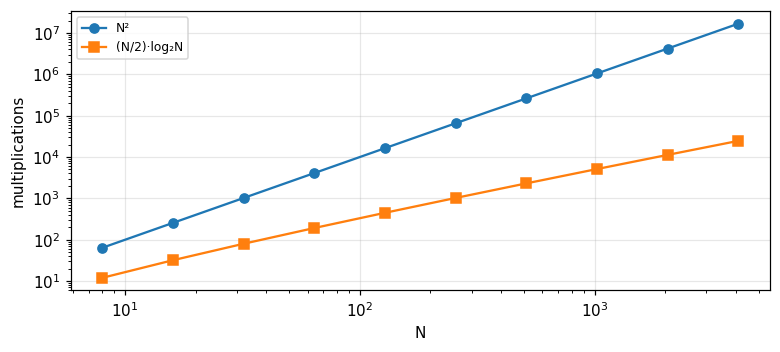

In [4]:
Ns = 2**np.arange(3, 13)
fig, ax = plt.subplots(figsize=(7.2, 3.3))
ax.loglog(Ns, Ns.astype(float)**2, "o-", label="N²"); ax.loglog(Ns, Ns/2*np.log2(Ns), "s-", label="(N/2)·log₂N")
ax.set_xlabel("N"); ax.set_ylabel(("multiplications")); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
8-point FFT: 12 multiplications (7, 3, 2); $N=1024$: 5120 against 1048576. Even/odd split $F(0)$ = 4.5, bit reversal 4, 2. $N=365$ deviates 6e-12. Zero padding: modulus differs 5e-15, leakage 0.095.

## 3. DFT error, tapers, convolution by FFT, power spectra
🎯 **What question does this method answer?** How large are aliasing, leakage and Hann tapering, how far is the DFT of $e^{-t/4}$ from the FT, and what is the relative deviation of the raw power spectrum?

In [5]:
# aliasing
n64 = np.arange(64); xa = np.cos(2*np.pi*0.75*n64)
assert np.argmax(np.abs(np.fft.rfft(xa))) == 16; report("al_v", 16, "d")
# leakage: 10 and 10.5 cycles, rectangular and Hann
def leak(k0, taper=False):
    x = np.cos(2*np.pi*k0*n64/64)
    if taper: x = x*(0.5 - 0.5*np.cos(2*np.pi*n64/64))
    P = np.abs(np.fft.rfft(x))**2
    c = int(round(k0)); m = P[max(c-2, 0):c+3].sum()
    return 1 - m/P.sum()
lk_i = leak(10); lk_r = leak(10.5); lk_h = leak(10.5, True)
assert lk_i < 1e-20 and lk_h < lk_r
report("lk_int", max(lk_i, 1e-16), ".0e"); report("lk_rect", lk_r, ".4f"); report("lk_hann", lk_h, ".4f")
# Hann = three-coefficient convolution
xx = rg.standard_normal(64); wv = 0.5 - 0.5*np.cos(2*np.pi*n64/64)
Fx = dft(xx); Fw = dft(xx*wv)
Fthree = 0.5*Fx - 0.25*np.roll(Fx, 1) - 0.25*np.roll(Fx, -1)
assert np.allclose(Fw, Fthree)
report("hn_c", 0.5, ".2f"); report("hn_s", -0.25, ".2f"); report("hn_dev", max(np.max(np.abs(Fw - Fthree)), 1e-16), ".0e")
# Problem 10: exp(−τ/4)
Nn = 32; tt = np.arange(Nn); fe = np.exp(-tt/4); fe[0] = 0.5
Fe = dft(fe); V = lambda fr: 1/(0.25 + 2j*np.pi*fr)
z = lambda nu_: np.exp(-0.25 - 2j*np.pi*nu_/Nn)
geo = np.array([(1 - z(nu_)**32)/(1 - z(nu_)) - 0.5 for nu_ in range(Nn)])
assert np.allclose(Nn*Fe, geo)
e0 = abs(Nn*Fe[0] - V(0))/abs(V(0)); e8 = abs(Nn*Fe[8] - V(8/Nn))/abs(V(8/Nn))
assert e0 < 0.01 and e8 > e0
report("ft_dft0", (Nn*Fe[0]).real, ".4f"); report("ft_err0", e0, ".4f"); report("ft_err8", e8, ".4f")
report("ft_geo", max(np.max(np.abs(Nn*Fe - geo)), 1e-16), ".0e")
# convolution, autocorrelation by FFT
rect = np.ones(4)
wrap = np.real(np.fft.ifft(np.abs(np.fft.fft(rect))**2)); padded = np.real(np.fft.ifft(np.abs(np.fft.fft(np.r_[rect, np.zeros(4)]))**2))
assert np.allclose(wrap, [4, 4, 4, 4]) and np.allclose(padded, [4, 3, 2, 1, 0, 1, 2, 3])
assert np.allclose(np.correlate(rect, rect, "full"), [1, 2, 3, 4, 3, 2, 1])
report("ac_wrap", wrap[1], ".0f"); report("ac_pad1", padded[1], ".0f"); report("ac_len", len(np.correlate(rect, rect, "full")), "d")
# two-dimensional DFT
A = rg.standard_normal((6, 5)); F2 = np.fft.fft2(A)
man = np.array([[np.sum(A*np.exp(-2j*np.pi*(u*np.arange(6)[:, None]/6 + v_*np.arange(5)[None, :]/5))) for v_ in range(5)] for u in range(6)])
assert np.allclose(F2, man) and np.allclose(np.fft.fft(np.fft.fft(A, axis=0), axis=1), F2)
S = np.zeros((8, 8)); S[0, 0] = 4; S[1, 0] = S[7, 0] = S[0, 1] = S[0, 7] = 2; S[1, 1] = S[7, 7] = S[1, 7] = S[7, 1] = 1
Fs = np.fft.fft2(S); assert np.max(np.abs(Fs.imag)) < 1e-12
Fh = np.fft.fft2(np.roll(S, (2, 3), axis=(0, 1))); assert np.allclose(np.abs(Fh), np.abs(Fs)) and np.max(np.abs(Fh.imag)) > 0.1
report("im_sym", max(np.max(np.abs(Fs.imag)), 1e-16), ".0e"); report("im_shift", np.max(np.abs(Fh.imag)), ".2f")
# power spectrum
def pgram(Nv, trials):
    return np.abs(np.fft.rfft(rg.standard_normal((trials, Nv)), axis=1)[:, 1:Nv//2])**2
P256 = pgram(256, 300); P4096 = pgram(4096, 60)
r256 = P256.std()/P256.mean(); r4096 = P4096.std()/P4096.mean()
assert abs(r256 - 1) < 0.05 and abs(r4096 - 1) < 0.05
report("pg_256", r256, ".1f"); report("pg_4096", r4096, ".1f")
m16 = P4096[:, :(P4096.shape[1]//16)*16].reshape(60, -1, 16).mean(2)
ra = m16.std()/m16.mean(); assert abs(ra - 0.25) < 0.02
report("pg_avg16", ra, ".2f")
def band(Nv, trials):
    P = np.abs(np.fft.rfft(rg.standard_normal((trials, Nv)), axis=1))**2
    fr = np.fft.rfftfreq(Nv); idx = (fr >= 0.1) & (fr < 0.2)
    bp = P[:, idx].sum(1); return bp.std()/bp.mean(), idx.sum()
b256, n256 = band(256, 1500); b4096, n4096 = band(4096, 400)
assert abs(b256 - 1/np.sqrt(n256)) < 0.03 and abs(b4096 - 1/np.sqrt(n4096)) < 0.008
report("bp_256", b256, ".2f"); report("bp_4096", b4096, ".2f")

▸ al_v = 16
▸ lk_int = 1e-16
▸ lk_rect = 0.0852
▸ lk_hann = 0.0005
▸ hn_c = 0.5
▸ hn_s = -0.25
▸ hn_dev = 2e-15
▸ ft_dft0 = 4.0193
▸ ft_err0 = 0.0048
▸ ft_err8 = 0.2199
▸ ft_geo = 1e-15
▸ ac_wrap = 4
▸ ac_pad1 = 3
▸ ac_len = 7
▸ im_sym = 1e-16
▸ im_shift = 13.66


▸ pg_256 = 1
▸ pg_4096 = 1
▸ pg_avg16 = 0.25
▸ bp_256 = 0.19
▸ bp_4096 = 0.05


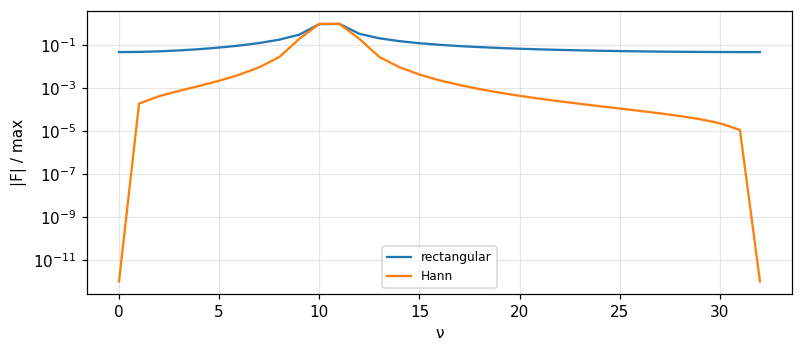

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 3.3))
for k0_, tap, lab in ((10.5, False, ("rectangular")), (10.5, True, "Hann")):
    x_ = np.cos(2*np.pi*k0_*n64/64)*((0.5 - 0.5*np.cos(2*np.pi*n64/64)) if tap else 1)
    ax.semilogy(np.abs(np.fft.rfft(x_))/np.abs(np.fft.rfft(x_)).max() + 1e-12, label=lab)
ax.set_xlabel("ν"); ax.set_ylabel("|F| / max"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
Aliasing at 16; leakage 1e-16, 0.0852, 0.0005; Hann 0.5, -0.25, 2e-15; DFT against FT: 4.0193, errors 0.0048 and 0.2199; autocorrelation 4, 3, 7; 2D 1e-16, 13.66; power spectrum 1, 1, 0.25; band 0.19, 0.05.

## 4. Discrete processes: correlation matrix, spectrum, linear systems
🎯 **What question does this method answer?** Is the Toeplitz matrix positive semidefinite, does the spectral theorem hold, does the spectrum of $0.8^{|k|}$ match the formula, and does white noise through an FIR give the right autocorrelation?

In [7]:
from scipy.linalg import toeplitz
from scipy import signal
rho = 0.8; M = 4
R = toeplitz(rho**np.arange(M))
lam, V = np.linalg.eigh(R)
assert np.all(lam > 0) and np.allclose(V @ np.diag(lam) @ V.T, R) and np.allclose(V.T @ V, np.eye(M))
assert abs(lam.sum() - np.trace(R)) < 1e-12 and abs(lam.sum() - M) < 1e-12
assert np.allclose(np.sort(np.roots(np.poly(R)).real), lam) and np.allclose(np.sort(np.linalg.eigvalsh(np.linalg.inv(R))), np.sort(1/lam))
ld = lam[::-1]
report("R_l1", ld[0], ".4f"); report("R_l2", ld[1], ".4f"); report("R_l3", ld[2], ".4f"); report("R_l4", ld[3], ".4f"); report("R_tr", lam.sum(), ".0f")
report("R_orth", max(np.max(np.abs(V.T @ V - np.eye(M))), 1e-16), ".0e")
report("R_rec", max(np.max(np.abs(V @ np.diag(lam) @ V.T - R)), 1e-16), ".0e")
report("R_inv", 1/lam.min(), ".4f")
report("ar_r1", rho, ".1f")
# spectrum
w = np.linspace(-np.pi, np.pi, 20001); k = np.arange(-400, 401)
S_sum = np.array([np.sum(rho**np.abs(k)*np.exp(-1j*wi*k)) for wi in w[::100]]).real
S_cf = (1 - rho**2)/(1 - 2*rho*np.cos(w) + rho**2)
assert np.allclose(S_sum, S_cf[::100], atol=1e-9)
r0 = trap(S_cf, w)/(2*np.pi); r3 = trap(S_cf*np.cos(3*w), w)/(2*np.pi)
assert abs(r0 - 1) < 1e-6 and abs(r3 - rho**3) < 1e-6
assert ld[0] <= S_cf.max() + 1e-9 and ld[-1] >= S_cf.min() - 1e-9
report("ws_S0", S_cf[10000], ".0f"); report("ws_Spi", (1 - rho**2)/(1 + rho)**2, ".4f"); report("ws_r3", r3, ".3f")
# white noise through an FIR
h = np.array([1, 0.5, 0.25]); ryy = [np.sum(h[:3-kk]*h[kk:]) for kk in range(3)]
assert np.allclose(ryy, [1.3125, 0.625, 0.25])
Hw = h[0] + h[1]*np.exp(-1j*w) + h[2]*np.exp(-2j*w); Syy = np.abs(Hw)**2
r_spec = [trap(Syy*np.cos(kk*w), w)/(2*np.pi) for kk in range(3)]
assert np.allclose(r_spec, ryy, atol=1e-6)
e_ = rg.standard_normal(400000); y_ = np.convolve(e_, h, "valid")
ry_sim = [np.mean(y_[:len(y_)-kk]*y_[kk:]) for kk in range(3)]
assert np.allclose(ry_sim, ryy, atol=0.02)
report("yy0", ryy[0], ".4f"); report("yy1", ryy[1], ".3f"); report("yy2", ryy[2], ".2f")
report("yy_int", r_spec[1], ".3f"); report("yy_sim", ry_sim[1], ".2f")

▸ R_l1 = 3.1032
▸ R_l2 = 0.5593
▸ R_l3 = 0.2088
▸ R_l4 = 0.1287
▸ R_tr = 4
▸ R_orth = 4e-16
▸ R_rec = 1e-15
▸ R_inv = 7.7675
▸ ar_r1 = 0.8
▸ ws_S0 = 9
▸ ws_Spi = 0.1111
▸ ws_r3 = 0.512
▸ yy0 = 1.3125
▸ yy1 = 0.625
▸ yy2 = 0.25
▸ yy_int = 0.625
▸ yy_sim = 0.62


#### 📤 Real output
Eigenvalues 3.1032, 0.5593, 0.2088, 0.1287 (sum 4); orthogonality 4e-16, reconstruction 1e-15; spectrum 9, 0.1111, $r(3)$ = 0.512; FIR 1.3125, 0.625, 0.25, integral 0.625, simulation 0.62.

## 5. AR, MA, ARMA, Yule-Walker, Markov chains
🎯 **What question does this method answer?** Do the variance, autocorrelation and spectrum formulas of AR, MA and ARMA match simulation and spectral integration, does Yule-Walker recover the parameters, and do the discrete and continuous Markov chains reproduce the book's numbers?

In [8]:
from scipy.linalg import expm
# AR(1)
a1 = -0.8; sn2 = 1.0; sx2 = sn2/(1 - a1**2)
xs = signal.lfilter([1], [1, a1], rg.standard_normal(400000))
assert abs(xs.var() - sx2) < 0.06
kk = np.arange(-3000, 3001); S0 = np.sum((-a1)**np.abs(kk)*sx2)
assert abs(S0 - sn2/(1 + a1)**2) < 1e-6
fgrid = np.linspace(-0.5, 0.5, 200001)
Sf1 = sn2/(1 + 2*a1*np.cos(2*np.pi*fgrid) + a1**2); assert abs(trap(Sf1, fgrid) - sx2) < 1e-6
report("ar1_var", sx2, ".4f"); report("ar1_r3", (-a1)**3*sx2, ".4f"); report("ar1_S0", S0, ".0f")
report("ar1_Spi", sn2/(1 - a1)**2, ".4f"); report("ar1_edge", 1/(1 - 0.99**2), ".2f"); report("ar1_sim", xs.var(), ".1f")
# AR(2)
b1, b2 = -0.5, 0.3
rho1 = -b1/(1 + b2); rho2 = b1**2/(1 + b2) - b2
sx2b = (1 + b2)/((1 - b2)*(1 + b1 + b2)*(1 - b1 + b2))
assert abs(sx2b - 1/(1 + b1*rho1 + b2*rho2)) < 1e-12
poles = np.roots([1, b1, b2]); assert np.all(np.abs(poles) < 1)
Hf = 1/(1 + b1*np.exp(-2j*np.pi*fgrid) + b2*np.exp(-4j*np.pi*fgrid)); assert abs(trap(np.abs(Hf)**2, fgrid) - sx2b) < 1e-6
x2 = signal.lfilter([1], [1, b1, b2], rg.standard_normal(300000))
r_h = np.array([np.mean(x2[:len(x2)-q]*x2[q:]) for q in range(3)])
assert abs(r_h[0] - sx2b) < 0.03 and abs(r_h[1] - rho1*sx2b) < 0.03
report("ar2_rho1", rho1, ".4f"); report("ar2_rho2", rho2, ".4f"); report("ar2_var", sx2b, ".4f"); report("ar2_pole", np.max(np.abs(poles)), ".4f")
pu = np.roots([1, -1.8, 0.5]); assert np.max(np.abs(pu)) > 1
report("ar2_unst", np.max(np.abs(pu)), ".4f")
cases = rg.uniform(-2.5, 2.5, size=(20000, 2)); cases[:, 1] = rg.uniform(-1.5, 1.5, size=20000); mis = 0
for c1, c2 in cases:
    tri = (-1 < c2 < 1) and (-(c1 + c2) < 1) and (c1 - c2 < 1)
    st_ = np.max(np.abs(np.roots([1, c1, c2]))) < 1
    mis += int(tri != st_)
assert mis == 0
report("tri_n", 20000, "d"); report("tri_mis", mis, "d")
# Yule-Walker
r_ex = np.array([sx2b, rho1*sx2b, rho2*sx2b])
Rm = toeplitz(r_ex[:2]); aw = -np.linalg.solve(Rm, r_ex[1:3]); s2 = r_ex[0] + aw[0]*r_ex[1] + aw[1]*r_ex[2]
assert np.allclose(aw, [b1, b2]) and abs(s2 - 1) < 1e-12
report("yw_a1", aw[0], ".1f"); report("yw_a2", aw[1], ".1f"); report("yw_s2", s2, ".0f")
Rh = toeplitz(r_h[:2]); ah = -np.linalg.solve(Rh, r_h[1:3]); s2h = r_h[0] + ah[0]*r_h[1] + ah[1]*r_h[2]
assert np.allclose(ah, [b1, b2], atol=0.02) and abs(s2h - 1) < 0.03
report("yw_h1", ah[0], ".2f"); report("yw_h2", ah[1], ".2f"); report("yw_hs", s2h, ".2f")
# MA(2)
b = np.array([1, 0.6, 0.3]); rma = [np.sum(b[:3-q]*b[q:]) for q in range(4)] if False else [np.sum(b[:3-q]*b[q:]) for q in range(3)]
assert np.allclose(rma, [1.45, 0.78, 0.3])
xm = np.convolve(rg.standard_normal(400000), b, "valid")
assert abs(np.mean(xm[:-1]*xm[1:]) - 0.78) < 0.02 and abs(np.mean(xm[:-3]*xm[3:])) < 0.02
Sm0 = np.abs(b.sum())**2; assert abs(Sm0 - 3.61) < 1e-12
report("ma_var", rma[0], ".2f"); report("ma_r1", rma[1], ".2f"); report("ma_r2", rma[2], ".1f"); report("ma_S0", Sm0, ".2f")
# ARMA(1,1)
hh = signal.lfilter([1, 0.4], [1, -0.5], np.r_[1, np.zeros(5000)])
ra = [np.sum(hh[:len(hh)-q]*hh[q:]) for q in range(4)]
assert abs(ra[0] - 2.08) < 1e-9 and abs(ra[1] - 1.44) < 1e-9 and abs(ra[2] - 0.5*ra[1]) < 1e-9 and abs(ra[3] - 0.5*ra[2]) < 1e-9 and abs(ra[1] - 0.5*ra[0]) > 0.3
report("arma_r0", ra[0], ".2f"); report("arma_r1", ra[1], ".2f"); report("arma_r2", ra[2], ".2f"); report("arma_ratio", ra[2]/ra[1], ".1f"); report("arma_S0", (1.4/0.5)**2, ".2f")
# discrete Markov chain
P = np.array([[.5, .2, .3], [.1, .4, .5], [.2, .1, .7]])
assert np.allclose(P @ P, [[.33, .21, .46], [.19, .23, .58], [.25, .15, .6]]) and np.allclose(np.linalg.matrix_power(P, 3), [[.278, .196, .526], [.234, .188, .578], [.26, .17, .57]])
wl, vl = np.linalg.eig(P.T); pi = np.real(vl[:, np.argmin(np.abs(wl - 1))]); pi = pi/pi.sum()
assert np.allclose(pi, [.26, .18, .56], atol=1e-12) and np.allclose(np.linalg.matrix_power(P, 50)[1], pi, atol=1e-12)
l2 = sorted(np.abs(np.linalg.eigvals(P)))[-2]
assert abs(l2 - np.sqrt(0.10)) < 1e-9
n_ = 1
while np.max(np.abs(np.linalg.matrix_power(P, n_) - pi)) > 1e-3: n_ += 1
report("mk_pi1", pi[0], ".2f"); report("mk_pi2", pi[1], ".2f"); report("mk_pi3", pi[2], ".2f"); report("mk_l2", l2, ".4f"); report("mk_n", n_, "d")
P2 = np.array([[.65, .35], [.45, .55]]); w2, v2 = np.linalg.eig(P2.T); pi2 = np.real(v2[:, np.argmin(np.abs(w2 - 1))]); pi2 = pi2/pi2.sum()
assert np.allclose(pi2, [0.5625, 0.4375]) and abs(sorted(np.linalg.eigvals(P2))[0] - 0.2) < 1e-12
assert np.allclose(np.linalg.matrix_power(P2, 7)[0], pi2, atol=1e-4)
pa = np.array([.3, .7]); p1 = pa @ P2; p2 = p1 @ P2
assert np.allclose(p1, [.51, .49]) and np.allclose(p2, [.552, .448])
report("m2_pi1", pi2[0], ".4f"); report("m2_pi2", pi2[1], ".4f"); report("m2_l2", 0.2, ".1f"); report("m2_p1", p1[0], ".2f"); report("m2_p2", p2[0], ".3f")
report("p3_a", np.linalg.matrix_power(P, 3)[0, 2], ".3f"); report("p3_c", np.linalg.matrix_power(P, 3)[2, 2], ".2f")
p0b = np.array([.2, .25, .35]); report("e45_sum", p0b.sum(), ".1f"); report("e45_bsum", 3*0.225, ".3f")
p0c = np.array([.2, .25, .55]); pc1 = p0c @ P; assert abs(pc1.sum() - 1) < 1e-12
report("e45_p1a", pc1[0], ".3f"); report("e45_p1b", pc1[1], ".3f"); report("e45_p1c", pc1[2], ".2f")
P5 = np.linalg.matrix_power(P, 5); ckd = np.max(np.abs(P5 - np.linalg.matrix_power(P, 2) @ np.linalg.matrix_power(P, 3)))
report("ck_dev", max(ckd, 1e-16), ".0e")
Psw = np.array([[0, 1], [1, 0.]]); from math import gcd; from functools import reduce
ret = [n for n in range(1, 21) if np.linalg.matrix_power(Psw, n)[0, 0] > 0]; d_ = reduce(gcd, ret); assert d_ == 2
report("per_d", d_, "d")
Pa = np.array([[1, 0, 0, 0], [.5, 0, .5, 0], [0, .5, 0, .5], [0, 0, 0, 1.]])
Q_ = Pa[1:3, 1:3]; R_ = Pa[1:3][:, [0, 3]]; Nf = np.linalg.inv(np.eye(2) - Q_); B = Nf @ R_
assert abs(B[0, 1] - 1/3) < 1e-12 and np.allclose(Nf.sum(1), [2, 2]) and abs(np.linalg.matrix_power(Pa, 300)[1, 3] - 1/3) < 1e-12
report("ab_13", B[0, 1], ".4f"); report("ab_steps", Nf.sum(1)[0], ".0f")
# continuous-time chain
bb, dd = 2.0, 3.0; Lg = np.array([[-bb, bb], [dd, -dd]])
p0t = lambda t: (1 - dd/(bb + dd))*np.exp(-(bb + dd)*t) + dd/(bb + dd)
pt = np.array([1, 0.])@expm(Lg*0.5); assert abs(pt[0] - p0t(0.5)) < 1e-12
report("ct_p0", p0t(0.5), ".4f"); report("ct_dev", max(abs(pt[0] - p0t(0.5)), 1e-16), ".0e"); report("ct_ss", dd/(bb + dd), ".1f"); report("ct_tau", 1/(bb + dd), ".1f")
lam_, mu_, Nb = 1.0, 2.0, 5
p0bd = 1/np.sum((lam_/mu_)**np.arange(Nb + 1)); pbd = p0bd*(lam_/mu_)**np.arange(Nb + 1)
Lb = np.zeros((Nb + 1, Nb + 1))
for q in range(Nb + 1):
    if q < Nb: Lb[q, q+1] = lam_
    if q > 0: Lb[q, q-1] = mu_
    Lb[q, q] = -Lb[q].sum()
assert np.allclose(pbd @ Lb, 0, atol=1e-12) and abs(pbd.sum() - 1) < 1e-12
report("bd_p0", pbd[0], ".4f"); report("bd_p1", pbd[1], ".4f"); report("bd_p5", pbd[5], ".4f")

▸ ar1_var = 2.7778
▸ ar1_r3 = 1.4222
▸ ar1_S0 = 25
▸ ar1_Spi = 0.3086
▸ ar1_edge = 50.25
▸ ar1_sim = 2.8
▸ ar2_rho1 = 0.3846
▸ ar2_rho2 = -0.1077
▸ ar2_var = 1.2897
▸ ar2_pole = 0.5477
▸ ar2_unst = 1.4568


▸ tri_n = 20000
▸ tri_mis = 0
▸ yw_a1 = -0.5
▸ yw_a2 = 0.3
▸ yw_s2 = 1
▸ yw_h1 = -0.5
▸ yw_h2 = 0.3
▸ yw_hs = 1
▸ ma_var = 1.45
▸ ma_r1 = 0.78
▸ ma_r2 = 0.3
▸ ma_S0 = 3.61
▸ arma_r0 = 2.08
▸ arma_r1 = 1.44
▸ arma_r2 = 0.72
▸ arma_ratio = 0.5
▸ arma_S0 = 7.84
▸ mk_pi1 = 0.26
▸ mk_pi2 = 0.18
▸ mk_pi3 = 0.56
▸ mk_l2 = 0.3162
▸ mk_n = 7
▸ m2_pi1 = 0.5625
▸ m2_pi2 = 0.4375
▸ m2_l2 = 0.2
▸ m2_p1 = 0.51
▸ m2_p2 = 0.552
▸ p3_a = 0.526
▸ p3_c = 0.57
▸ e45_sum = 0.8
▸ e45_bsum = 0.675
▸ e45_p1a = 0.235
▸ e45_p1b = 0.195
▸ e45_p1c = 0.57
▸ ck_dev = 1e-16
▸ per_d = 2
▸ ab_13 = 0.3333
▸ ab_steps = 2
▸ ct_p0 = 0.6328
▸ ct_dev = 4e-16
▸ ct_ss = 0.6
▸ ct_tau = 0.2
▸ bd_p0 = 0.5079
▸ bd_p1 = 0.254
▸ bd_p5 = 0.0159


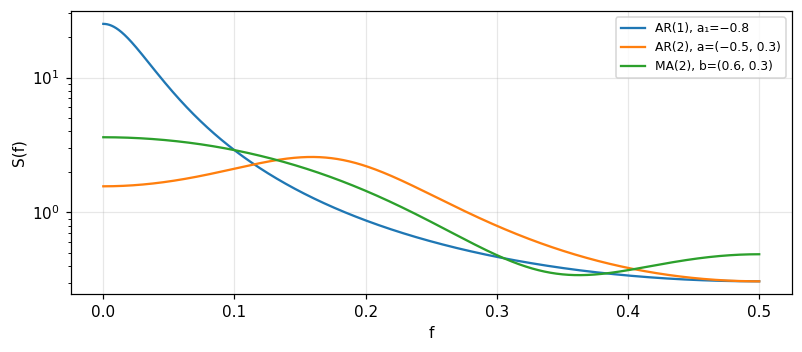

In [9]:
fig, ax = plt.subplots(figsize=(7.4, 3.3))
ax.semilogy(fgrid[100000:], Sf1[100000:], label="AR(1), a₁=−0.8")
ax.semilogy(fgrid[100000:], np.abs(Hf[100000:])**2, label="AR(2), a=(−0.5, 0.3)")
fm = fgrid[100000:]; ax.semilogy(fm, np.abs(1 + 0.6*np.exp(-2j*np.pi*fm) + 0.3*np.exp(-4j*np.pi*fm))**2, label="MA(2), b=(0.6, 0.3)")
ax.set_xlabel("f"); ax.set_ylabel("S(f)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
AR(1): 2.7778, 1.4222, $S(0)$ = 25. AR(2): 0.3846, -0.1077, 1.2897, pole 0.5477. Yule-Walker: -0.5, 0.3, 1; from data -0.5, 0.3, 1. MA(2): 1.45, 0.78, 0.3. ARMA: 2.08, 1.44, 0.72. Markov: 0.26, 0.18, 0.56, $|\lambda_2|$ = 0.3162; two states 0.5625; absorbing 0.3333; continuous 0.6328; birth-death 0.5079.